# Task 5: Exploratory Data Analysis (EDA)
**Name:** Ankita Daweshar  
**Internship:** Elevate Labs - Data Analyst Intern  
**Date:** 04 June 2026  
**Dataset:** Titanic Dataset (Kaggle)

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

os.makedirs('src', exist_ok=True)
print("✅ src folder created!")

✅ src folder created!


In [34]:
df = pd.read_csv(r"C:\Users\dawes\OneDrive\Desktop\ElevateLabs-Task5\Titanic-Dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Missing Values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


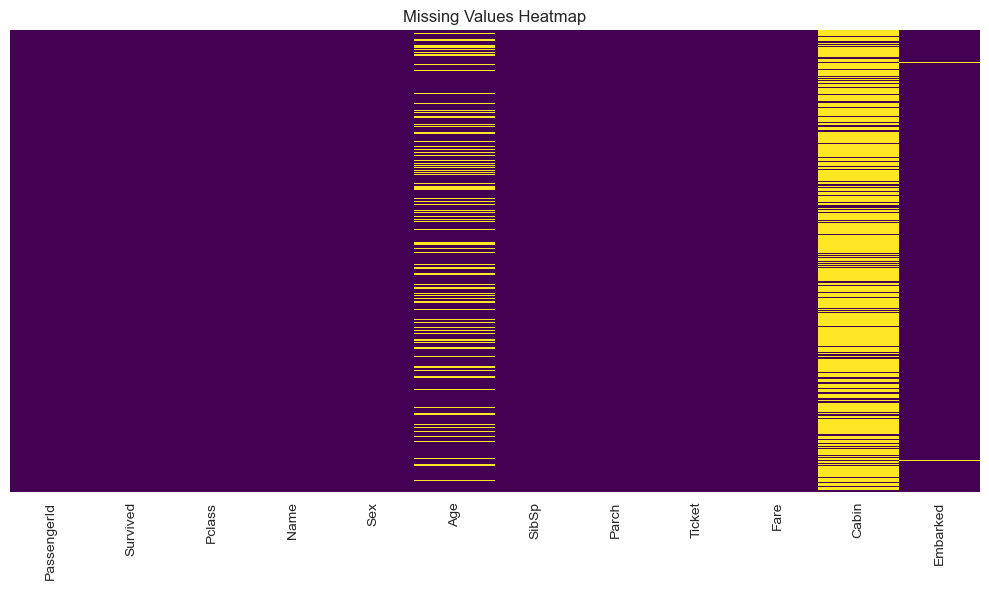

In [36]:
print("Missing Values:\n")
print(df.isnull().sum())

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.savefig('src/01_missing_values_heatmap.png', dpi=150)
plt.show()

In [37]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [38]:
# Fill Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin (too many nulls)
df.drop(columns=['Cabin'], inplace=True)

print("Missing after cleaning:\n", df.isnull().sum())

Missing after cleaning:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## 📊 Univariate Analysis

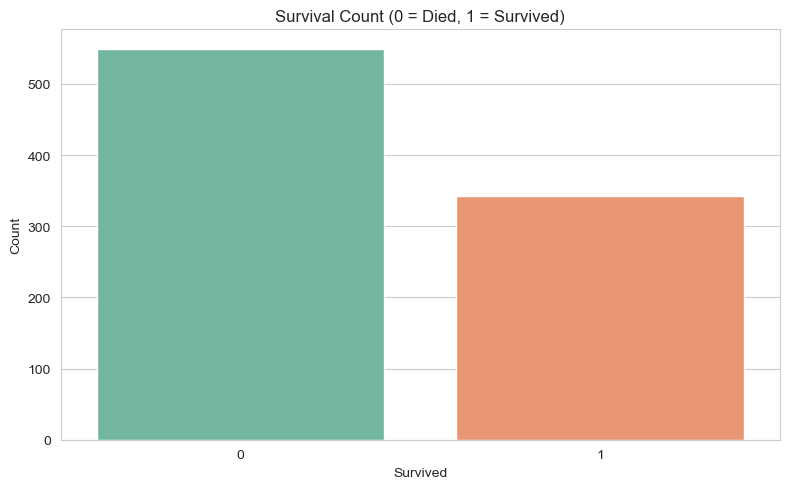

Survived
0    549
1    342
Name: count, dtype: int64


In [39]:
plt.figure(figsize=(8,5))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title("Survival Count (0 = Died, 1 = Survived)")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig('src/02_survival_count.png', dpi=150)
plt.show()
print(df['Survived'].value_counts())

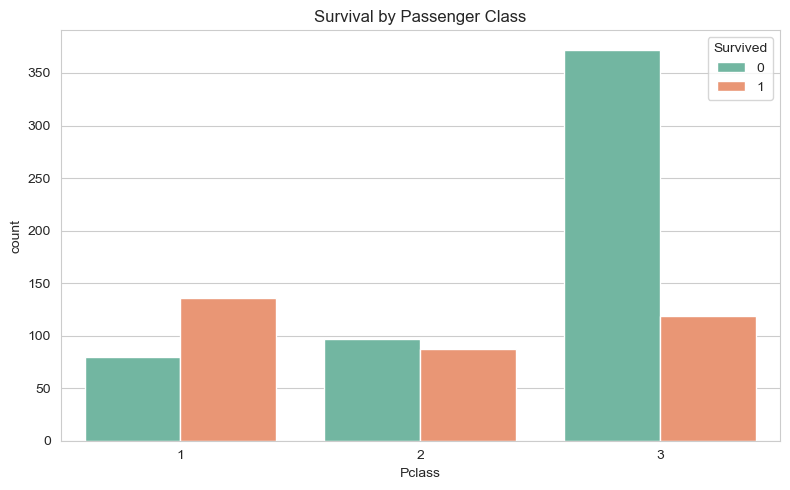

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [40]:
plt.figure(figsize=(8,5))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set2')
plt.title("Survival by Passenger Class")
plt.tight_layout()
plt.savefig('src/03_survival_by_class.png', dpi=150)
plt.show()
print(df.groupby('Pclass')['Survived'].mean())

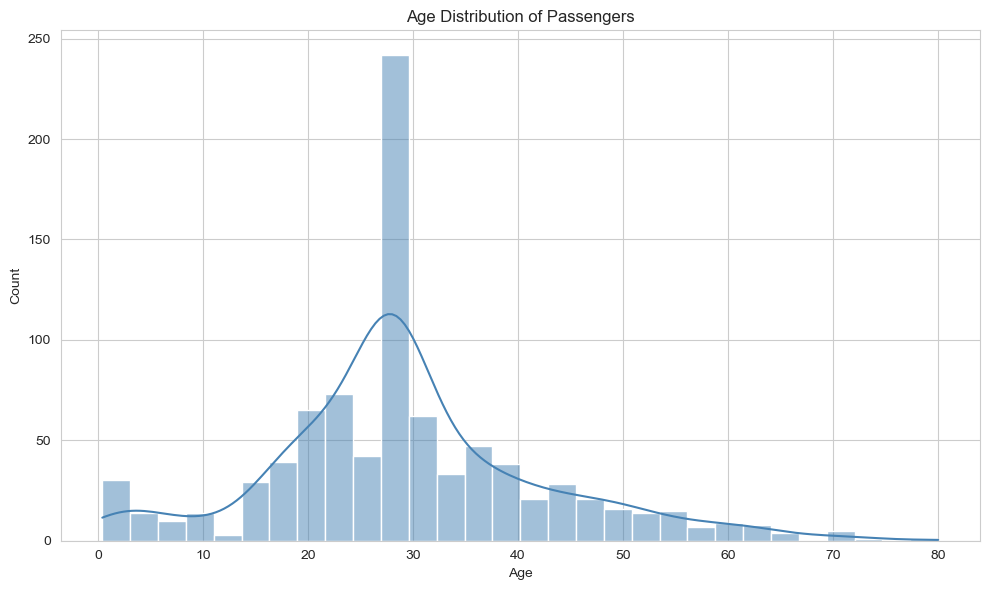

In [41]:
plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=30, kde=True, color='steelblue')
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig('src/04_age_distribution.png', dpi=150)
plt.show()

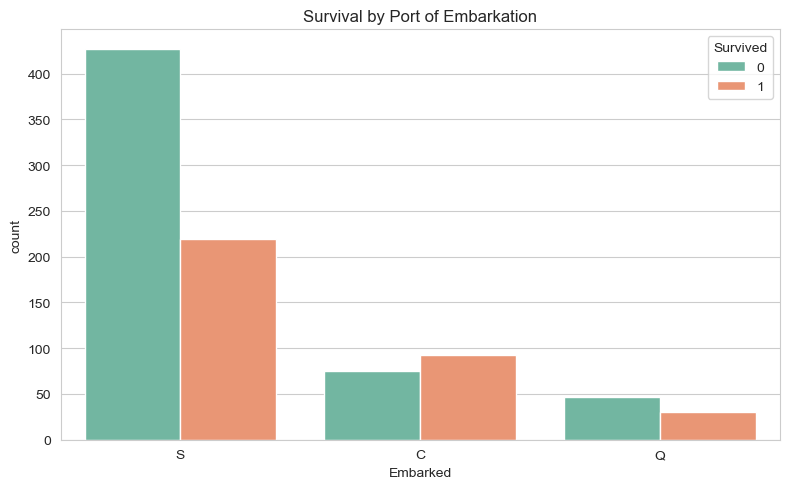

In [42]:
plt.figure(figsize=(8,5))
sns.countplot(x='Embarked', hue='Survived', data=df, palette='Set2')
plt.title("Survival by Port of Embarkation")
plt.tight_layout()
plt.savefig('src/05_survival_by_embarked.png', dpi=150)
plt.show()

## 📊 Multivariate Analysis

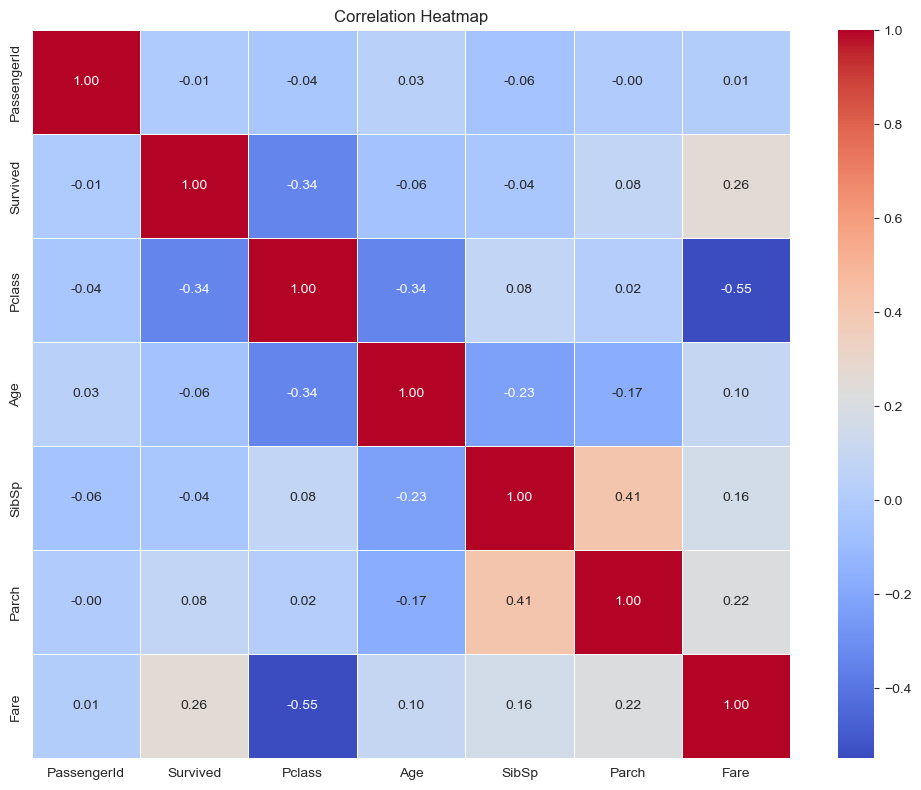

In [43]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', 
            cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig('src/06_correlation_heatmap.png', dpi=150)
plt.show()

c:\Users\dawes\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


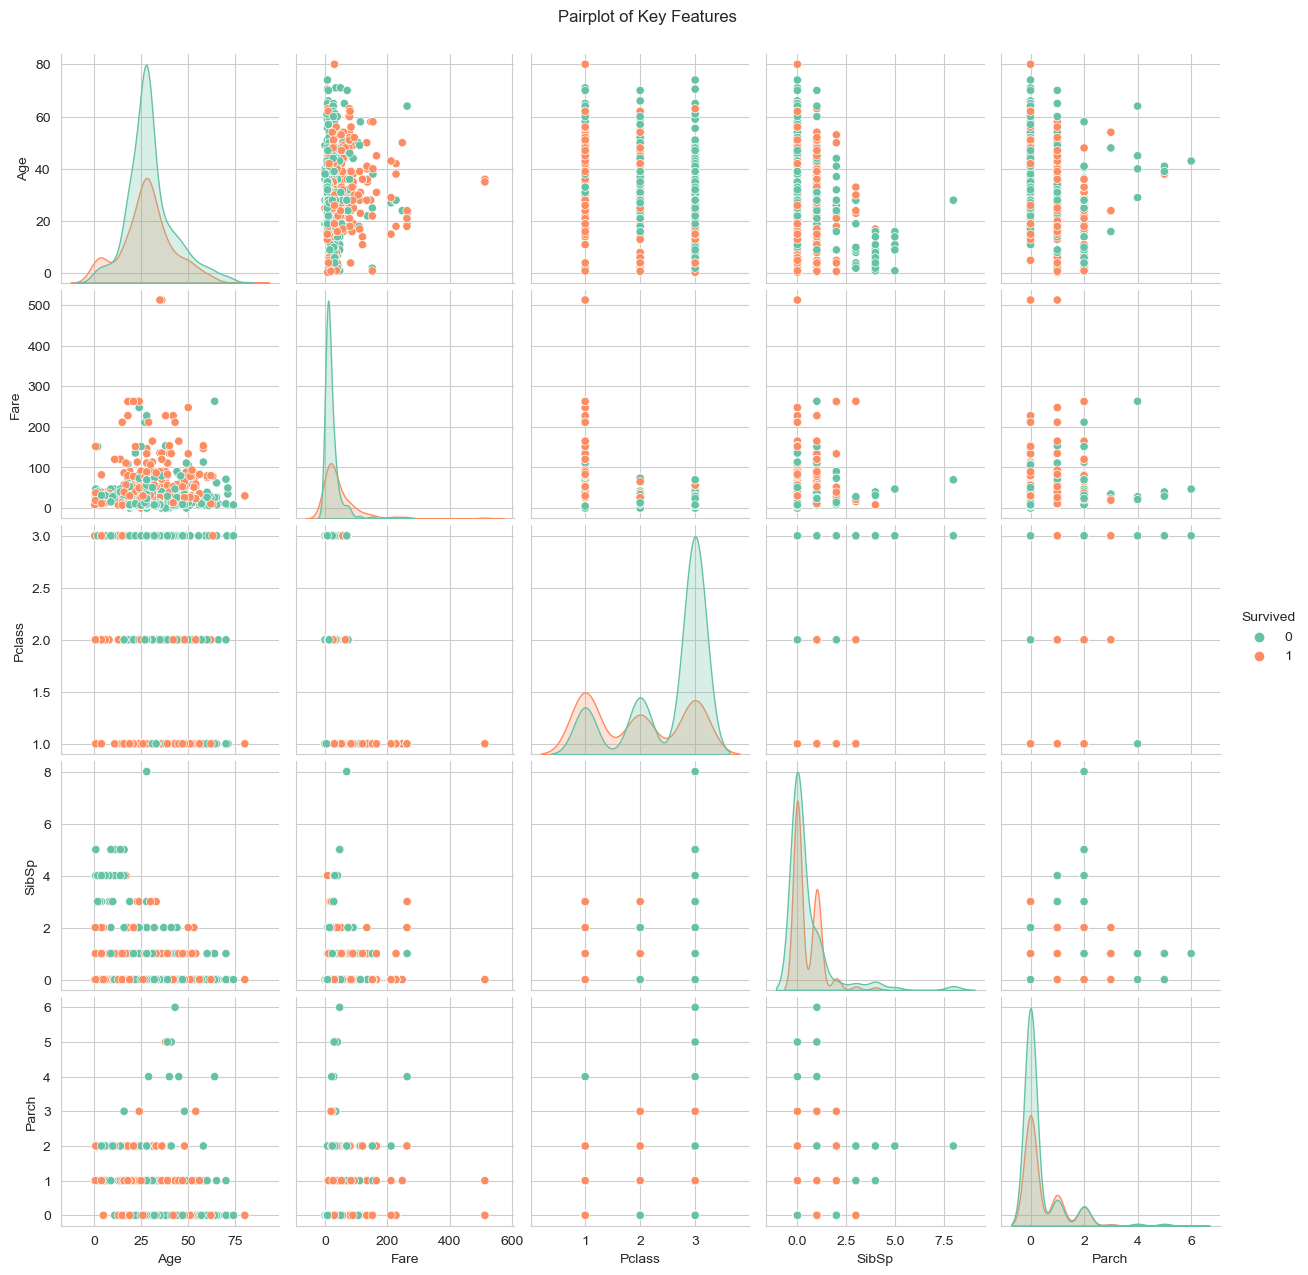

In [44]:
sns.pairplot(df[['Survived','Age','Fare','Pclass','SibSp','Parch']], 
             hue='Survived', palette='Set2')
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.savefig('src/07_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

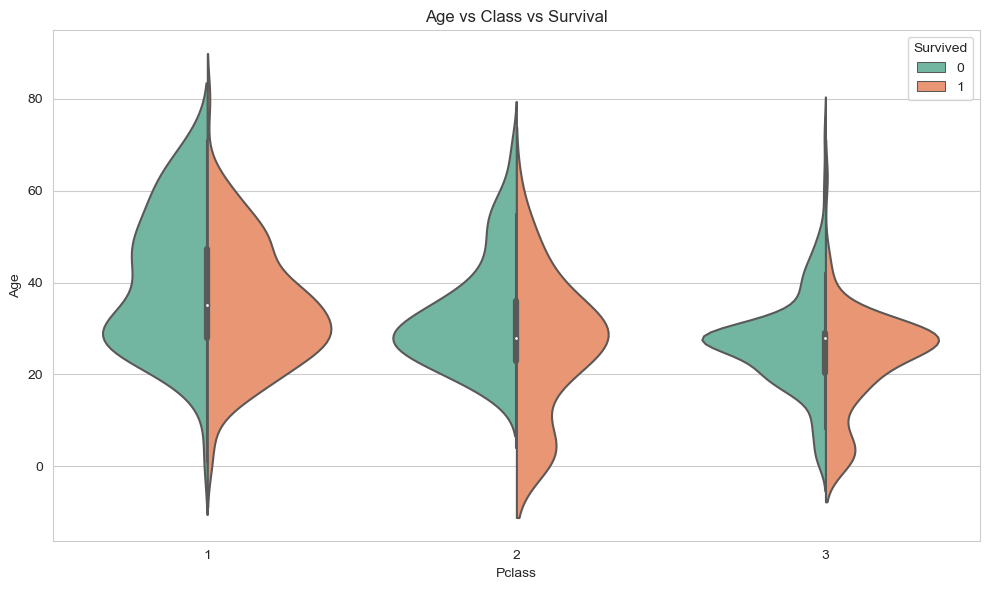

In [45]:
plt.figure(figsize=(10,6))
sns.violinplot(x='Pclass', y='Age', hue='Survived', 
               data=df, split=True, palette='Set2')
plt.title("Age vs Class vs Survival")
plt.tight_layout()
plt.savefig('src/08_violin_age_class_survival.png', dpi=150)
plt.show()

## ✅ Key Findings & Summary

1. **Survival Rate:** Only 38% of passengers survived
2. **Gender:** Females had 74% survival rate vs 19% for males → "Women first" policy evident
3. **Class:** 1st class passengers had highest survival (63%), 3rd class lowest (24%)
4. **Age:** Children had higher survival rates; middle-aged males had lowest
5. **Fare:** Higher fare passengers had better survival chances
6. **Embarkation:** Passengers from Cherbourg (C) had highest survival rate
7. **Family:** Passengers with 1-2 family members had better survival than alone or large families

### Conclusion
The Titanic survival was strongly influenced by **gender, passenger class, and age**.
Socioeconomic status played a major role in determining survival chances.